In [ ]:
# In the name of GOD, the Most Gracious, the Most Merciful                                                                                                                                                                                                                                                                                                                                                                                  # In the name of GOD Most Gracious Most Merciful

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import math

In [3]:
import copy

In [4]:
def calculate_f1(precision, recall):

    if (
        precision is None
        or
        recall is None
    ):
        return None

    denominator = precision + recall

    if denominator == 0:
        return None

    return (
        2 * precision * recall
    ) / denominator

In [5]:
def calculate_gmean(recall, specificity):

    if (
        recall is None
        or
        specificity is None
    ):
        return None

    return math.sqrt(
        recall * specificity
    )

In [6]:
# Here, "alert_list_without_Normal" contains Normal alerts as well because as explained in the experiments Normal alerts are not removed from "alert_list_without_Normal" and the same name is used for it for consistency 
# Initialise empty lists to store data
all_Number_total_alerts = []
all_mean_q_values = []
all_max_q_values = []
all_q_values_state = []
all_reward = []
all_alert_list_without_Normal = []
all_alert_list_without_Normal_with_revised_priority = []
all_alert_list_without_Normal_without_revised_priority = []
all_alert_after_action_01 = []
all_Final_alert_list_without_Normal_addressed = []
all_Final_alert_list_without_Normal_NotAddressed = []
all_Analyst_workload = []
all_Remaining_time = []
all_len_Critical_storage = []
all_len_High_storage = []
all_len_Moderate_storage = []
all_len_Low_storage = []
all_len_Normal_storage = []
all_time_step_execution_time = []

#all_Execution_time = []




for i in range(1,2017): 
    
    file_path = rf'C:\\...\\AlertPro_CICIDS2017_time_step_{i}.json'
                   
    # read the JSON file
    with open(file_path, 'r') as json_file:
        data = json.load(json_file)
  
    number_total_alerts = data["Number_total_alerts"]
    all_Number_total_alerts.append(number_total_alerts)
    
    mean_q_values = data["Mean_Q_values"]
    all_mean_q_values.append(mean_q_values)
    
    max_q_values = data["Max_Q_values"]
    all_max_q_values.append(max_q_values)
    
    q_values_state = data["Q_value_each_state_average"]
    all_q_values_state.append(q_values_state)
    
    reward = data["Reward"]
    all_reward.append(reward)
    
    alert_list_without_Normal = data["alert_list_without_Normal"]
    all_alert_list_without_Normal.append(alert_list_without_Normal)
    
    alert_list_without_Normal_with_revised_priority = data["alert_list_without_Normal_with_revised_priority"]
    all_alert_list_without_Normal_with_revised_priority.append(alert_list_without_Normal_with_revised_priority)

    alert_list_without_Normal_without_revised_priority = data["alert_list_without_Normal_without_revised_priority"]
    all_alert_list_without_Normal_without_revised_priority.append(alert_list_without_Normal_without_revised_priority)
    
    alert_after_action_01 = data["alerts_after_action_01"]
    all_alert_after_action_01.append(alert_after_action_01)
    
    Final_alert_list_without_Normal_addressed = data["Final_alert_list_without_Normal_addressed"]
    all_Final_alert_list_without_Normal_addressed.append(Final_alert_list_without_Normal_addressed)
    
    Final_alert_list_without_Normal_NotAddressed = data["Final_alert_list_without_Normal_NotAddressed"]
    all_Final_alert_list_without_Normal_NotAddressed.append(Final_alert_list_without_Normal_NotAddressed)

    time_step_execution_time = data["time_step_execution_time"]
    all_time_step_execution_time.append(time_step_execution_time)
    
    
    Analyst_workload = data["Analyst_Workload"]
    all_Analyst_workload.append(Analyst_workload)
    
    Remaining_time = data["Remaining_time"]
    all_Remaining_time.append(Remaining_time)
    

In [7]:
len(all_alert_list_without_Normal[1])

376

In [8]:
len(all_Final_alert_list_without_Normal_addressed[1])

19

In [9]:
len(all_Final_alert_list_without_Normal_NotAddressed[1])

357

In [10]:
# Initialize counts
priority_counts_without_Normal = {0.0: 0, 1.0: 0, 2.0: 0, 3.0: 0, 4.0: 0}

# Loop through all inner lists and alerts
for inner_list in all_alert_list_without_Normal:
    for alert in inner_list:
        priority = alert.get('priority_Analyst')
        if priority in priority_counts_without_Normal:
            priority_counts_without_Normal[priority] += 1

# Calculate average for each priority
total_alerts = sum(priority_counts_without_Normal.values())
average_per_priority = {priority: count / len(all_alert_list_without_Normal) for priority, count in priority_counts_without_Normal.items()}

# Display results
print("Priority counts_all_alert_list_without_Normal:", priority_counts_without_Normal)
print("Average alerts per priority_all_alert_list_without_Normal:", average_per_priority)

Priority counts_all_alert_list_without_Normal: {0.0: 648336, 1.0: 0, 2.0: 121599, 3.0: 36667, 4.0: 553}
Average alerts per priority_all_alert_list_without_Normal: {0.0: 321.5952380952381, 1.0: 0.0, 2.0: 60.316964285714285, 3.0: 18.18799603174603, 4.0: 0.2743055555555556}


In [11]:
# Initialize counts
priority_counts_without_Normal_addressed = {0.0: 0, 1.0: 0, 2.0: 0, 3.0: 0, 4.0: 0}

# Loop through all inner lists and alerts
for inner_list in all_Final_alert_list_without_Normal_addressed:
    for alert in inner_list:
        priority = alert.get('priority_Analyst')
        if priority in priority_counts_without_Normal_addressed:
            priority_counts_without_Normal_addressed[priority] += 1

# Calculate average for each priority
total_alerts = sum(priority_counts_without_Normal_addressed.values())
average_per_priority = {priority: count / len(all_Final_alert_list_without_Normal_addressed) for priority, count in priority_counts_without_Normal_addressed.items()}

# Display results
print("Priority counts_all_Final_alert_list_without_Normal_addressed:", priority_counts_without_Normal_addressed)
print("Average alerts per priority_all_Final_alert_list_without_Normal_addressed:", average_per_priority)

Priority counts_all_Final_alert_list_without_Normal_addressed: {0.0: 30679, 1.0: 0, 2.0: 5845, 3.0: 1755, 4.0: 25}
Average alerts per priority_all_Final_alert_list_without_Normal_addressed: {0.0: 15.217757936507937, 1.0: 0.0, 2.0: 2.8993055555555554, 3.0: 0.8705357142857143, 4.0: 0.01240079365079365}


In [12]:
# Total Number of without_Normal_addressed
sum_without_Normal_addressed = sum(priority_counts_without_Normal_addressed.values())

print("Total Number of without_Normal_addressed =", sum_without_Normal_addressed)

Total Number of without_Normal_addressed = 38304


In [13]:
# Initialize counts
priority_counts_without_Normal_NotAddressed = {0.0: 0, 1.0: 0, 2.0: 0, 3.0: 0, 4.0: 0}

# Loop through all inner lists and alerts
for inner_list in all_Final_alert_list_without_Normal_NotAddressed:
    for alert in inner_list:
        priority = alert.get('priority_Analyst')
        if priority in priority_counts_without_Normal_NotAddressed:
            priority_counts_without_Normal_NotAddressed[priority] += 1

# Calculate average for each priority
total_alerts = sum(priority_counts_without_Normal_NotAddressed.values())
average_per_priority = {priority: count / len(all_Final_alert_list_without_Normal_NotAddressed) for priority, count in priority_counts_without_Normal_NotAddressed.items()}

# Display results
print("Priority counts_all_Final_alert_list_without_Normal_NotAddressed:", priority_counts_without_Normal_NotAddressed)
print("Average alerts per priority_all_Final_alert_list_without_Normal_NotAddressed:", average_per_priority)

Priority counts_all_Final_alert_list_without_Normal_NotAddressed: {0.0: 617657, 1.0: 0, 2.0: 115754, 3.0: 34912, 4.0: 528}
Average alerts per priority_all_Final_alert_list_without_Normal_NotAddressed: {0.0: 306.3774801587302, 1.0: 0.0, 2.0: 57.41765873015873, 3.0: 17.317460317460316, 4.0: 0.2619047619047619}


In [14]:
# Function to compute the division of values with the same keys
def compute_division(dict1, dict2):
    result = {}
    for key in dict1:
        if dict1[key] != 0:
            result[key] = dict2[key] / dict1[key]
        else:
            result[key] = float('inf') # Handle division by zero
    return result

# Compute the divisions
addressed_division = compute_division(priority_counts_without_Normal, priority_counts_without_Normal_addressed)
not_addressed_division = compute_division(priority_counts_without_Normal, priority_counts_without_Normal_NotAddressed)

# Print the results
print("Division of addressed alerts:", addressed_division)
print("Division of not addressed alerts:", not_addressed_division)

Division of addressed alerts: {0.0: 0.047319599713728684, 1.0: inf, 2.0: 0.04806782950517685, 3.0: 0.04786320124362506, 4.0: 0.045207956600361664}
Division of not addressed alerts: {0.0: 0.9526804002862713, 1.0: inf, 2.0: 0.9519321704948231, 3.0: 0.9521367987563749, 4.0: 0.9547920433996383}


In [15]:
len(all_Number_total_alerts)

2016

In [16]:
# Calculating the number of normal alerts
whole_alert_number = sum(all_Number_total_alerts)
print("whole_alert_number =",whole_alert_number)

whole_alert_number = 807155


In [17]:
whole_alert_number_without_normal = sum(priority_counts_without_Normal.values())
print("whole_alert_number_without_normal =",whole_alert_number_without_normal)

whole_alert_number_without_normal = 807155


In [18]:
whole_alert_number_normal = whole_alert_number - whole_alert_number_without_normal
print("whole_alert_number_normal =",whole_alert_number_normal)

whole_alert_number_normal = 0


In [19]:
# Number of processed alerts
number_processed_alerts = whole_alert_number_normal + sum(priority_counts_without_Normal_addressed.values())
print("number_processed_alerts= ", number_processed_alerts)

number_processed_alerts=  38304


In [20]:
# Number of un-processed alerts
number_un_processed_alerts = sum(priority_counts_without_Normal_NotAddressed.values())
print("number_un_processed_alerts= ", number_un_processed_alerts)

number_un_processed_alerts=  768851


In [21]:
percentage_processed_alerts = number_processed_alerts / whole_alert_number
print("percentage_processed_alerts =", percentage_processed_alerts)

percentage_processed_alerts = 0.04745556925249797


In [22]:
percentage_un_processed_alerts = number_un_processed_alerts / whole_alert_number
print("percentage_un_processed_alerts =", percentage_un_processed_alerts)

percentage_un_processed_alerts = 0.9525444307475021


In [23]:
number_Normal_alerts_addressed = number_processed_alerts - sum_without_Normal_addressed
print("number_Normal_alerts_addressed =", number_Normal_alerts_addressed)

number_Normal_alerts_addressed = 0


In [25]:
len(all_mean_q_values)

2016

In [28]:
len(all_Analyst_workload)

2016

In [29]:
len(all_len_Critical_storage)

0

In [30]:
len(all_alert_list_without_Normal_with_revised_priority)

2016

In [31]:
len(all_alert_list_without_Normal)

2016

In [32]:
len(all_Final_alert_list_without_Normal_NotAddressed[1710])

374

In [33]:
len(all_alert_list_without_Normal[1760])

380

In [34]:
new_all_alert_list_without_Normal = copy.deepcopy(all_alert_list_without_Normal)


In [35]:
labels = []

for alerts_list in new_all_alert_list_without_Normal:
    for alert in alerts_list:
        labels.append(alert['IF_label'])

print(set(labels))

{1, -1}


In [36]:
labels_10 = []

for alerts_list in new_all_alert_list_without_Normal:
    for alert in alerts_list:

        if alert['revised_priority'] == 10:
            labels_10.append(alert['IF_label'])

print(set(labels_10))
print(labels_10[:20])

{1, -1}
[1, -1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, -1, 1, 1, 1]


In [37]:
BBB = []
AAA = []
for alerts_list in new_all_alert_list_without_Normal:

    for alert in alerts_list:

        IF_label = int(alert['IF_label'])

        if alert['revised_priority'] == 10:

            if IF_label == 1:  # Normal

                prior = 0
                AAA.append(IF_label)

            else:  # Anomaly (-1)

                prior = 1
                BBB.append(IF_label)

            alert['revised_priority'] = prior

In [38]:
print(set(AAA))
print(AAA[:20])

{1}
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [39]:
print(set(BBB))
print(BBB[:20])

{-1}
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]


In [40]:
# Accuracy caculation for revised (AlertPro) total
accurate_overall_revised_total = 0
inaccurate_overall_revised_total = 0

accurate_without_normal_revised_total = 0
inaccurate_without_normal_revised_total = 0

accurate_normal_revised_total = 0
inaccurate_normal_revised_total = 0


for alert_list in new_all_alert_list_without_Normal:
    for alert in alert_list:
        if alert['revised_priority']==alert['priority_Analyst_label']:
            accurate_overall_revised_total = accurate_overall_revised_total + 1
        else:
            inaccurate_overall_revised_total = inaccurate_overall_revised_total + 1
            
        if alert['priority_Analyst_label']==0:
            if alert['revised_priority']==alert['priority_Analyst_label']:
                accurate_normal_revised_total = accurate_normal_revised_total + 1
            else:
                inaccurate_normal_revised_total = inaccurate_normal_revised_total + 1
            
        if alert['priority_Analyst_label']!=0:
            if alert['revised_priority']==alert['priority_Analyst_label']:
                accurate_without_normal_revised_total = accurate_without_normal_revised_total + 1
            else:
                inaccurate_without_normal_revised_total = inaccurate_without_normal_revised_total + 1
            

accuracy_overall_revised_total = accurate_overall_revised_total / (accurate_overall_revised_total+inaccurate_overall_revised_total)
accuracy_normal_revised_total = accurate_normal_revised_total / (accurate_normal_revised_total+inaccurate_normal_revised_total)
accuracy_without_normal_revised_total = (accurate_without_normal_revised_total / (accurate_without_normal_revised_total+inaccurate_without_normal_revised_total)) if (accurate_without_normal_revised_total+inaccurate_without_normal_revised_total) != 0 else None

print('accuracy_overall_revised_total =', accuracy_overall_revised_total)
print('accuracy_normal_revised_total =', accuracy_normal_revised_total)
print('accuracy_without_normal_revised_total =', accuracy_without_normal_revised_total)

accuracy_overall_revised_total = 0.7501136708562791
accuracy_normal_revised_total = 0.8420402383949064
accuracy_without_normal_revised_total = 0.3748480975198182


In [41]:
# False positive and negatives, revised total (AlertPro)
accurate_overall_revised_total_1 = 0
inaccurate_overall_revised_total_1 = 0
accurate_overall_revised_total_0 = 0
inaccurate_overall_revised_total_0 = 0



for alert_list in new_all_alert_list_without_Normal:
    for alert in alert_list:
        if alert['revised_priority']==alert['priority_Analyst_label']:
            if alert['priority_Analyst_label'] == 1:
                accurate_overall_revised_total_1 = accurate_overall_revised_total_1 + 1
            elif alert['priority_Analyst_label'] == 0:
                accurate_overall_revised_total_0 = accurate_overall_revised_total_0 + 1
            else:
                print('Error: priority_Analyst_label is different from 1 and 0')
        else: # alert['revised_priority'] != alert['priority_Analyst_label']:
            if alert['priority_Analyst_label'] == 1: # false negatives
                inaccurate_overall_revised_total_0 = inaccurate_overall_revised_total_0 + 1
            elif alert['priority_Analyst_label'] == 0: # false positives
                inaccurate_overall_revised_total_1 = inaccurate_overall_revised_total_1 + 1
            else:
                print('Error: priority_Analyst_label is different from 1 and 0')
                

accuracy_revised_total_check = (accurate_overall_revised_total_1 + accurate_overall_revised_total_0) / (accurate_overall_revised_total_1 + accurate_overall_revised_total_0 + inaccurate_overall_revised_total_1 + inaccurate_overall_revised_total_0) 
Number_revised_total = accurate_overall_revised_total_1 + accurate_overall_revised_total_0 + inaccurate_overall_revised_total_1 + inaccurate_overall_revised_total_0

print("False positives, inaccurate_overall_revised_total_1 =", inaccurate_overall_revised_total_1)
print()
print("False negatives, inaccurate_overall_revised_total_0 =", inaccurate_overall_revised_total_0)
print()
print("True positives (1), accurate_overall_revised_total_1 =", accurate_overall_revised_total_1)
print()
print("True negatives (0), accurate_overall_revised_total_0 =", accurate_overall_revised_total_0)
print()
print("accuracy_revised_total_check =", accuracy_revised_total_check)
print()
print("Number_revised_total =", Number_revised_total)
print()

False positives, inaccurate_overall_revised_total_1 = 102411

False negatives, inaccurate_overall_revised_total_0 = 99286

True positives (1), accurate_overall_revised_total_1 = 59533

True negatives (0), accurate_overall_revised_total_0 = 545925

accuracy_revised_total_check = 0.7501136708562791

Number_revised_total = 807155



In [42]:
### Percision, Recall, F1_Score, G-mean for revised total 
# another approach

# Precision
Precision_Overall_revised_total_2 = accurate_overall_revised_total_1 / (accurate_overall_revised_total_1 + inaccurate_overall_revised_total_1)

# Recall
Recall_Overall_revised_total_2 = accurate_overall_revised_total_1 / (accurate_overall_revised_total_1 + inaccurate_overall_revised_total_0)  

# Specificity
Specificity_Overall_revised_total_2 = accurate_overall_revised_total_0 / (accurate_overall_revised_total_0 + inaccurate_overall_revised_total_1)

# F1_Score 
F1_Score_Overall_revised_total_2 = calculate_f1(Precision_Overall_revised_total_2, Recall_Overall_revised_total_2)

# G_mean
G_mean_Overall_revised_total_2 = calculate_gmean(Recall_Overall_revised_total_2, Specificity_Overall_revised_total_2) 



print("Precision_Overall_revised_total_2 =", Precision_Overall_revised_total_2)
print("Recall_Overall_revised_total_2 =", Recall_Overall_revised_total_2)
print("Specificity_Overall_revised_total_2 =", Specificity_Overall_revised_total_2)
print("F1_Score_Overall_revised_total_2 =", F1_Score_Overall_revised_total_2)
print("G_mean_Overall_revised_total_2 =", G_mean_Overall_revised_total_2)



Precision_Overall_revised_total_2 = 0.36761473101812975
Recall_Overall_revised_total_2 = 0.3748480975198182
Specificity_Overall_revised_total_2 = 0.8420402383949064
F1_Score_Overall_revised_total_2 = 0.37119617911043357
G_mean_Overall_revised_total_2 = 0.5618159675529566


In [43]:
# Accuracy, Percision, Recall, F1_Score, G-mean revised (AlertPro) total_every time step
# For graphs and P_values
# another approach

# lists to calculate Accuracies of each time step
Accuracy_Overall_revised_total_list_2 = []

# lists to calculate Percisions of each time step
Precision_Overall_revised_total_list_2 = []


# lists to calculate Recalls of each time step
Recall_Overall_revised_total_list_2 = []


# lists to calculate F1_Scores of each time step
F1_Score_Overall_revised_total_list_2 = []


# lists to calculate G_means of each time step
G_mean_Overall_revised_total_list_2 = []



for alert_list in new_all_alert_list_without_Normal:

    # False prioritisation revised total
    accurate_overall_revised_total_time_step_1 = 0
    inaccurate_overall_revised_total_time_step_1 = 0
    accurate_overall_revised_total_time_step_0 = 0
    inaccurate_overall_revised_total_time_step_0 = 0
    
    
    
    for alert in alert_list:
        
        if alert['revised_priority']==alert['priority_Analyst_label']:
            if alert['priority_Analyst_label'] == 1:
                accurate_overall_revised_total_time_step_1 = accurate_overall_revised_total_time_step_1 + 1
            elif alert['priority_Analyst_label'] == 0:
                accurate_overall_revised_total_time_step_0 = accurate_overall_revised_total_time_step_0 + 1
            else:
                print('Error: priority_Analyst_label is different from 1 and 0')
        else: # alert['revised_priority'] != alert['priority_Analyst_label']:
            if alert['priority_Analyst_label'] == 1: # false negatives
                inaccurate_overall_revised_total_time_step_0 = inaccurate_overall_revised_total_time_step_0 + 1
            elif alert['priority_Analyst_label'] == 0: # false positives
                inaccurate_overall_revised_total_time_step_1 = inaccurate_overall_revised_total_time_step_1 + 1
            else:
                print('Error: priority_Analyst_label is different from 1 and 0')
                
        
        
    # Metric calculation    
    # Accuracy
    Accuracy_Overall_revised_total_time_step_2 = (accurate_overall_revised_total_time_step_1 + accurate_overall_revised_total_time_step_0) / (
        accurate_overall_revised_total_time_step_1 + accurate_overall_revised_total_time_step_0 + 
     inaccurate_overall_revised_total_time_step_1 + inaccurate_overall_revised_total_time_step_0) if (accurate_overall_revised_total_time_step_1 + 
                                                                                                      accurate_overall_revised_total_time_step_0 + 
                                                                                                      inaccurate_overall_revised_total_time_step_1 + 
                                                                                                      inaccurate_overall_revised_total_time_step_0) != 0 else None

    # Precision
    Precision_Overall_revised_total_time_step_2 = accurate_overall_revised_total_time_step_1 / (
        accurate_overall_revised_total_time_step_1 + inaccurate_overall_revised_total_time_step_1) if (accurate_overall_revised_total_time_step_1 + 
                                                                                                    inaccurate_overall_revised_total_time_step_1) != 0 else None

    # Recall
    Recall_Overall_revised_total_time_step_2 = accurate_overall_revised_total_time_step_1 / (
        accurate_overall_revised_total_time_step_1 + inaccurate_overall_revised_total_time_step_0)  if (accurate_overall_revised_total_time_step_1 + 
                                                                                                     inaccurate_overall_revised_total_time_step_0) != 0 else None

    # Specificity
    Specificity_Overall_revised_total_time_step_2 = accurate_overall_revised_total_time_step_0 / (
        accurate_overall_revised_total_time_step_0 + inaccurate_overall_revised_total_time_step_1) if (accurate_overall_revised_total_time_step_0 + 
                                                                                                    inaccurate_overall_revised_total_time_step_1) != 0 else None

    # F1_Score 
    F1_Score_Overall_revised_total_time_step_2 = calculate_f1(Precision_Overall_revised_total_time_step_2, Recall_Overall_revised_total_time_step_2)

    # G_mean
    G_mean_Overall_revised_total_time_step_2 = calculate_gmean(Recall_Overall_revised_total_time_step_2, Specificity_Overall_revised_total_time_step_2)

    
    
    # Append Acuuracies of time steps to the lists
    Accuracy_Overall_revised_total_list_2.append(Accuracy_Overall_revised_total_time_step_2) 
    
    # Append Precisions of time steps to the lists
    Precision_Overall_revised_total_list_2.append(Precision_Overall_revised_total_time_step_2) 
    
    
    # Append Recalls of time steps to the lists
    Recall_Overall_revised_total_list_2.append(Recall_Overall_revised_total_time_step_2) 
    
    
    # Append F1_Scores of time steps to the lists
    F1_Score_Overall_revised_total_list_2.append(F1_Score_Overall_revised_total_time_step_2) 
    
    # Append G_means of time steps to the lists
    G_mean_Overall_revised_total_list_2.append(G_mean_Overall_revised_total_time_step_2) 
    
        
    

# for duoble check
def calculate_MeanStd(data):
    values = [d for d in data if d is not None]
    mean_val = np.mean(values)
    std_val = np.std(values)
    return mean_val, std_val

# Accuracy
mean_Accuracy_Overall_revised_total_2, std_Accuracy_Overall_revised_total_2 = calculate_MeanStd(Accuracy_Overall_revised_total_list_2)

print('mean_Accuracy_Overall_revised_total_2 =', mean_Accuracy_Overall_revised_total_2, 'std_Accuracy_Overall_revised_total_2 =', std_Accuracy_Overall_revised_total_2)
print()

# Precision
mean_Precision_Overall_revised_total_2, std_Precision_Overall_revised_total_2 = calculate_MeanStd(Precision_Overall_revised_total_list_2)

print('mean_Precision_Overall_revised_total_2 =', mean_Precision_Overall_revised_total_2, 'std_Precision_Overall_revised_total_2 =', std_Precision_Overall_revised_total_2)
print()

# Recall
mean_Recall_Overall_revised_total_2, std_Recall_Overall_revised_total_2 = calculate_MeanStd(Recall_Overall_revised_total_list_2)

print('mean_Recall_Overall_revised_total_2 =', mean_Recall_Overall_revised_total_2, 'std_Recall_Overall_revised_total_2 =', std_Recall_Overall_revised_total_2)
print()

# F1_Score
mean_F1_Score_Overall_revised_total_2, std_F1_Score_Overall_revised_total_2 = calculate_MeanStd(F1_Score_Overall_revised_total_list_2)

print('mean_F1_Score_Overall_revised_total_2 =', mean_F1_Score_Overall_revised_total_2, 'std_F1_Score_Overall_revised_total_2 =', std_F1_Score_Overall_revised_total_2)
print()

# G_mean
mean_G_mean_Overall_revised_total_2, std_G_mean_Overall_revised_total_2 = calculate_MeanStd(G_mean_Overall_revised_total_list_2)

print('mean_G_mean_Overall_revised_total_2 =', mean_G_mean_Overall_revised_total_2, 'std_G_mean_Overall_revised_total_2 =', std_G_mean_Overall_revised_total_2)
print()

mean_Accuracy_Overall_revised_total_2 = 0.7501591026077454 std_Accuracy_Overall_revised_total_2 = 0.02111871968016373

mean_Precision_Overall_revised_total_2 = 0.36766971069394044 std_Precision_Overall_revised_total_2 = 0.05340015255276642

mean_Recall_Overall_revised_total_2 = 0.3749534134529262 std_Recall_Overall_revised_total_2 = 0.05383858255800875

mean_F1_Score_Overall_revised_total_2 = 0.36980732423973006 std_F1_Score_Overall_revised_total_2 = 0.04808762281074666

mean_G_mean_Overall_revised_total_2 = 0.5604070805483292 std_G_mean_Overall_revised_total_2 = 0.041010119837020416



In [ ]:
# A dictionary to hold all the Precision lists
data = {
    "Accuracy_Overall_revised_total_list_2_AlertPro_CICIDS2017": Accuracy_Overall_revised_total_list_2,
    "Precision_Overall_revised_total_list_2_AlertPro_CICIDS2017": Precision_Overall_revised_total_list_2,
    "Recall_Overall_revised_total_list_2_AlertPro_CICIDS2017": Recall_Overall_revised_total_list_2,
    "F1_Score_Overall_revised_total_list_2_AlertPro_CICIDS2017": F1_Score_Overall_revised_total_list_2,
    "G_mean_Overall_revised_total_list_2_AlertPro_CICIDS2017": G_mean_Overall_revised_total_list_2,
}

# Write the dictionary to a JSON file
with open('All_metric_data_AlertPro_CICIDS2017.json', 'w') as json_file:
    json.dump(data, json_file, indent=4)

In [ ]:
# Execution time

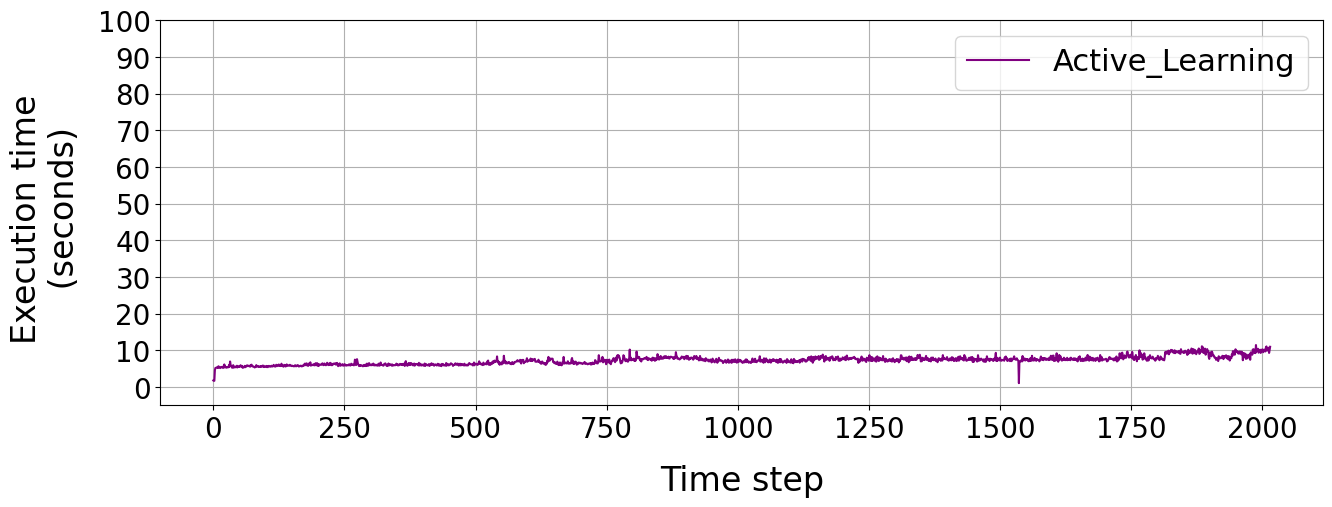

In [44]:
plt.figure(figsize=(15, 5))
plt.plot(all_time_step_execution_time, c='purple')

plt.xlabel("Time step", fontsize=24, labelpad=15)
plt.ylabel("Execution time \n (seconds)", fontsize=24, labelpad=12)
plt.ylim(-5, 100)
plt.yticks(range(0, 101, 10), fontsize=20)
plt.legend(fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid()
plt.show()

In [45]:
with open('all_time_step_execution_time_AlertPro_CICIDS2017.json', 'w') as f:
    json.dump(all_time_step_execution_time, f)